In [55]:
import ndlib.models.ModelConfig as mc
import ndlib.models.epidemics as ep
from ndlib.utils import multi_runs
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import time # TODO: remove when done

## 2.1 Implement SIR and Simulate

Implement SIR disease spread on the network. Think about your experimental design
and which parameters of the model you will want to vary. Design code that will allow
you run multiple simulations while varying the disease parameter.

### Functions to generate network, model, and run SIR simulations

In [5]:
def create_network(network_type, num_nodes, seed = None, p = 0.01, m = 5, k = 6):
    if network_type == 'Erdos-Renyi':
        return nx.erdos_renyi_graph(num_nodes, p, seed)
    elif network_type == 'Barabasi-Albert':
        return nx.barabasi_albert_graph(num_nodes, m, seed)
    elif network_type == 'Watts-Strogatz':
        return nx.watts_strogatz_graph(num_nodes, k, p, seed)
    else:
        raise ValueError("Invalid network type. Choose from 'Erdos-Renyi', 'Barabasi-Albert', or 'Watts-Strogatz'.")

In [467]:
def generate_model(network, beta, gamma, initial_infected_fraction = None, initial_infected_nodes = None):
    # Create model
    model = ep.SIRModel(network)
    config = mc.Configuration()
    
    # Add model Parameters 
    config.add_model_parameter('beta', beta) 
    config.add_model_parameter('gamma', gamma)  

    # Set initial infected population (either by fraction or specific nodes)
    if initial_infected_fraction:
        config.add_model_parameter('percentage_infected', initial_infected_fraction)
    elif initial_infected_nodes is not None:
        config.add_model_initial_configuration('Infected', initial_infected_nodes)
    
    model.set_initial_status(config)

    return model

In [469]:
def run_sir_simulations(network, beta, gamma, initial_infected_fraction = None, initial_infected_nodes = None, iterations = 100, num_simulations = 50):
    # Generate the model
    model = generate_model(network, beta, gamma, initial_infected_fraction, initial_infected_nodes)

    # Run the model and retund results
    if initial_infected_fraction:
        return multi_runs(model, execution_number = num_simulations, iteration_number = iterations, nprocesses=4)
    elif initial_infected_nodes is not None:
        infection_sets = [initial_infected_nodes for _ in range(num_simulations)]
        return multi_runs(model, execution_number=num_simulations, iteration_number=iterations, infection_sets=infection_sets, nprocesses=4)
    else:
        raise ValueError("You need to provide either 'initial_infected_fraction' or 'initial_infected_nodes' parameter.")

## 2.2 Generate Networks of equivalent form

Using NetworkX generate multiple model networks with similar characteristics, again
think about the parameters associated with each network generator (e.g., Number of
nodes, connection probability,etc). Pick some network statistics (e.g., centrality measures,
degree distributions, etc.) that are interesting to measure in terms of spreading on the
network. You should generate multiple instances of each network type and then plot the
network statistics (you chose) and discuss how these statistic differ between network types
and for different parameter settings. You will use these generated networks in your SIR
experiments in the next part.

### Functions to measure basic network statistics

In [108]:
def get_diameter(network):
    return nx.diameter(network)

In [112]:
def get_average_path_length(network):
    return nx.average_shortest_path_length(network)

In [129]:
def get_average_clustering(network):
    return nx.average_clustering(network)

In [110]:
def get_average_degree(network):
    return 2 * network.number_of_edges() / network.number_of_nodes()

In [125]:
def show_degree_histogram(network, title = None):
    degree_histogram = nx.degree_histogram(network)

    degrees = range(len(degree_histogram))
    
    plt.bar(degrees, degree_histogram, color='lightgreen', edgecolor='black')
    
    plt.xlabel('Degree')
    plt.ylabel('Frequency')
    if title:
        plt.title(title)
    else:
        plt.title('Degree histogram')
    
    plt.show()

In [127]:
def show_degree_probability(network, title = None):
    degree_histogram = nx.degree_histogram(network)

    num_nodes = network.number_of_nodes()

    degree_probability = [frequency / num_nodes for frequency in degree_histogram]

    # Scatter plot of the probability
    plt.scatter(range(1, len(degree_histogram) + 1), degree_probability)

    plt.xlabel('Degree k')
    plt.ylabel('Probability p(k)')
    if title:
        plt.title(title)
    else:
        plt.title('Degree distribution')

    plt.show()

### Centrality measures

In [270]:
def get_average_degree_normalised(network):
    degree_centrality = nx.degree_centrality(network)
    
    return sum(c_d / num_nodes for c_d in degree_centrality.values())

In [274]:
def show_degree_centrality(network):
    degree_centrality = nx.degree_centrality(network)
    
    # Plot a histogram of degree centrality values
    plt.hist(list(degree_centrality.values()), bins=10, color='lightgreen', edgecolor='black')
    plt.title('Degree Centrality Distribution')
    plt.xlabel('Degree Centrality (normalised)')
    plt.ylabel('Frequency')
    plt.show()

In [276]:
def show_betweenness_centrality(network):
    betweenness_centrality = nx.betweenness_centrality(network)
    
    # Plot a histogram of betweenness centrality values
    plt.hist(list(betweenness_centrality.values()), bins=20, color='lightgreen', edgecolor='black')
    plt.title('Betweenness Centrality Distribution')
    plt.xlabel('Betweenness Centrality')
    plt.ylabel('Frequency')
    plt.show()

In [278]:
def show_betweenness_centrality(network):
    betweenness_centrality = nx.betweenness_centrality(network)
    
    # Plot a histogram of betweenness centrality values
    plt.hist(list(betweenness_centrality.values()), bins=20, color='lightgreen', edgecolor='black')
    plt.title('Betweenness Centrality Distribution')
    plt.xlabel('Betweenness Centrality')
    plt.ylabel('Frequency')
    plt.show()

### Generate multiple networks and show statistics

In [316]:
def print_basic_network_statistics(network):
    print('Diameter =', get_diameter(network))
    print('Average path length =', get_average_path_length(network))
    print('Average degree =', get_average_degree(network))
    print('Clustering coefficient =', get_average_clustering(network))
    print('Number of edges =', network.number_of_edges())
    print('------------------------------------')

In [283]:
def generate_multiple_networks(num_networks, network_type, num_nodes, seed, p = None, m = None, k = None):
    networks = []
    
    for n in range(num_networks):
        # Generate network
        network = create_network(network_type, num_nodes, seed = seed, p = p, k = k, m = m)
        networks.append(network)

        # Update seed
        seed += 1

    return networks

In [427]:
def plot_network_histograms(network, title):
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    
    # Plot degree histogram
    degree_histogram = nx.degree_histogram(network)
    degrees = range(len(degree_histogram))
    
    axs[0].bar(degrees, degree_histogram, color='darkolivegreen', edgecolor='black')
    axs[0].set_xlabel('Degree')
    axs[0].set_ylabel('Frequency')
    # axs[0].set_title('Degree Histogram')

    # Plot degree centrality
    degree_centrality = nx.degree_centrality(network)
    
    axs[1].hist(list(degree_centrality.values()), bins=10, color='olive', edgecolor='black')
    axs[1].set_xlabel('Degree Centrality (normalised)')
    axs[1].set_ylabel('Frequency')
    # axs[1].set_title('Degree Centrality Distribution')
    
    # Plot betweenness centrality
    betweenness_centrality = nx.betweenness_centrality(network)
    
    axs[2].hist(list(betweenness_centrality.values()), bins=20, color='goldenrod', edgecolor='black')
    axs[2].set_xlabel('Betweenness Centrality')
    axs[2].set_ylabel('Frequency')
    # axs[2].set_title('Betweenness Centrality Distribution')
    
    # Plot closeness centrality
    closeness_centrality = nx.closeness_centrality(network)
    
    axs[3].hist(list(closeness_centrality.values()), bins=20, color='palegoldenrod', edgecolor='black')
    axs[3].set_xlabel('Closeness Centrality')
    axs[3].set_ylabel('Frequency')
    # axs[3].set_title('Closeness Centrality Distribution')

    plt.tight_layout()
    plt.suptitle(title, fontsize=18)
    plt.subplots_adjust(top = 0.9)
    plt.show()

### Comparison of networks

#### Less connected networks

Erdos-Renyi
Diameter = 5
Average path length = 3.260664664664665
Average degree = 9.954
Clustering coefficient = 0.010245287667269091
Number of edges = 4977
------------------------------------
Barabasi-Albert
Diameter = 5
Average path length = 3.006162162162162
Average degree = 9.95
Clustering coefficient = 0.03417067064363123
Number of edges = 4975
------------------------------------
Watts-Strogatz
Diameter = 89
Average path length = 33.969813813813815
Average degree = 10.0
Clustering coefficient = 0.6658186868686868
Number of edges = 5000
------------------------------------


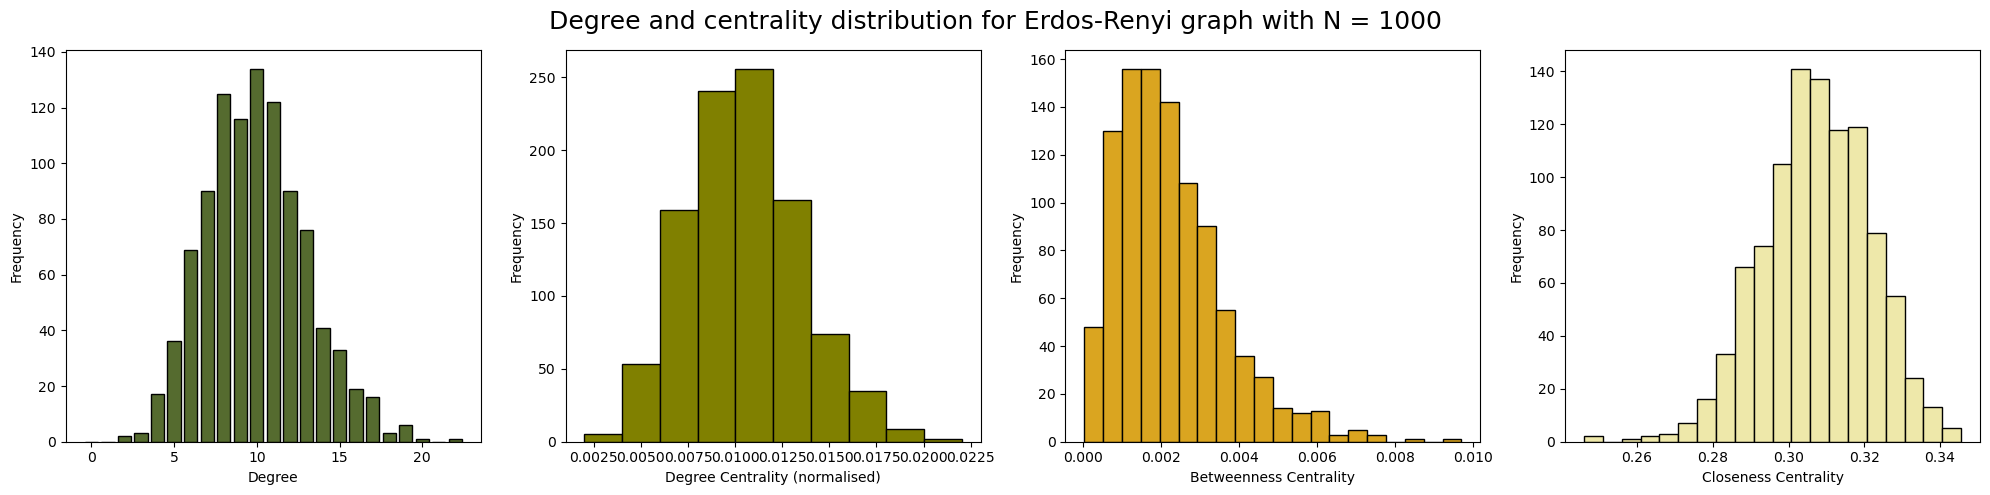

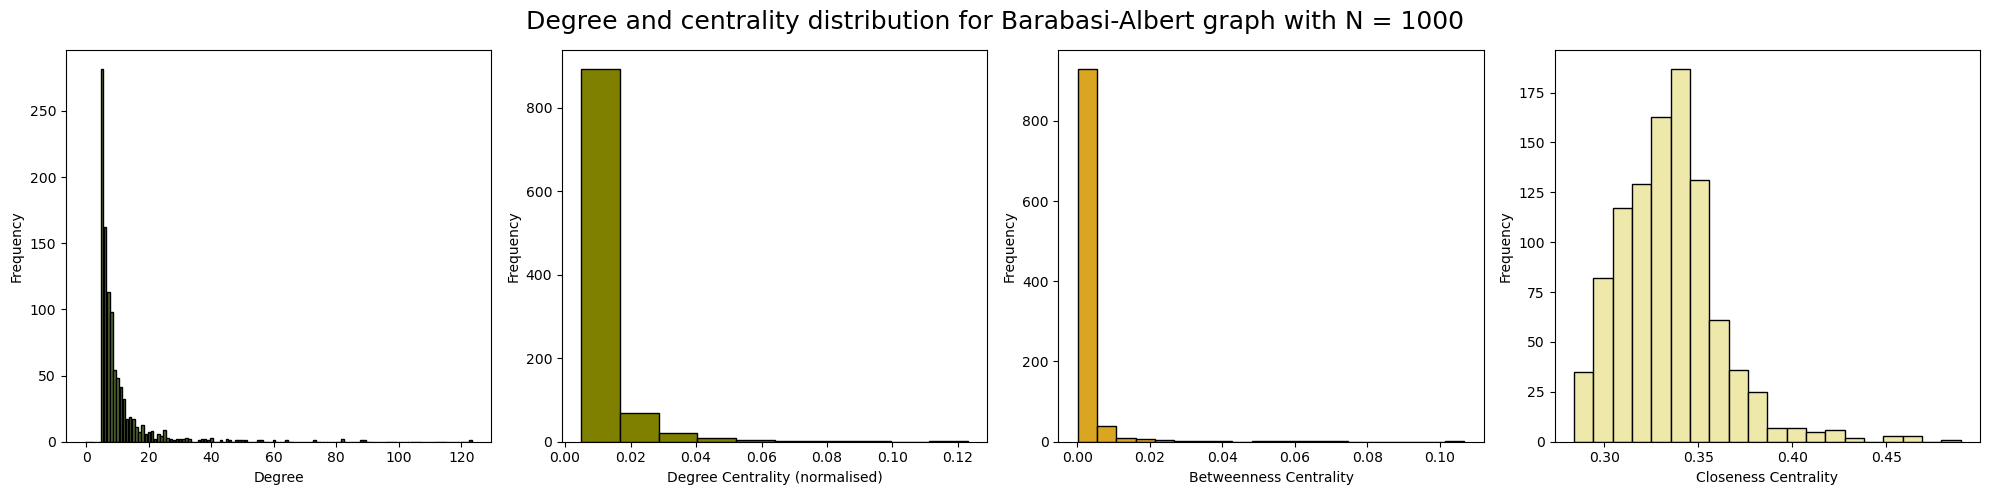

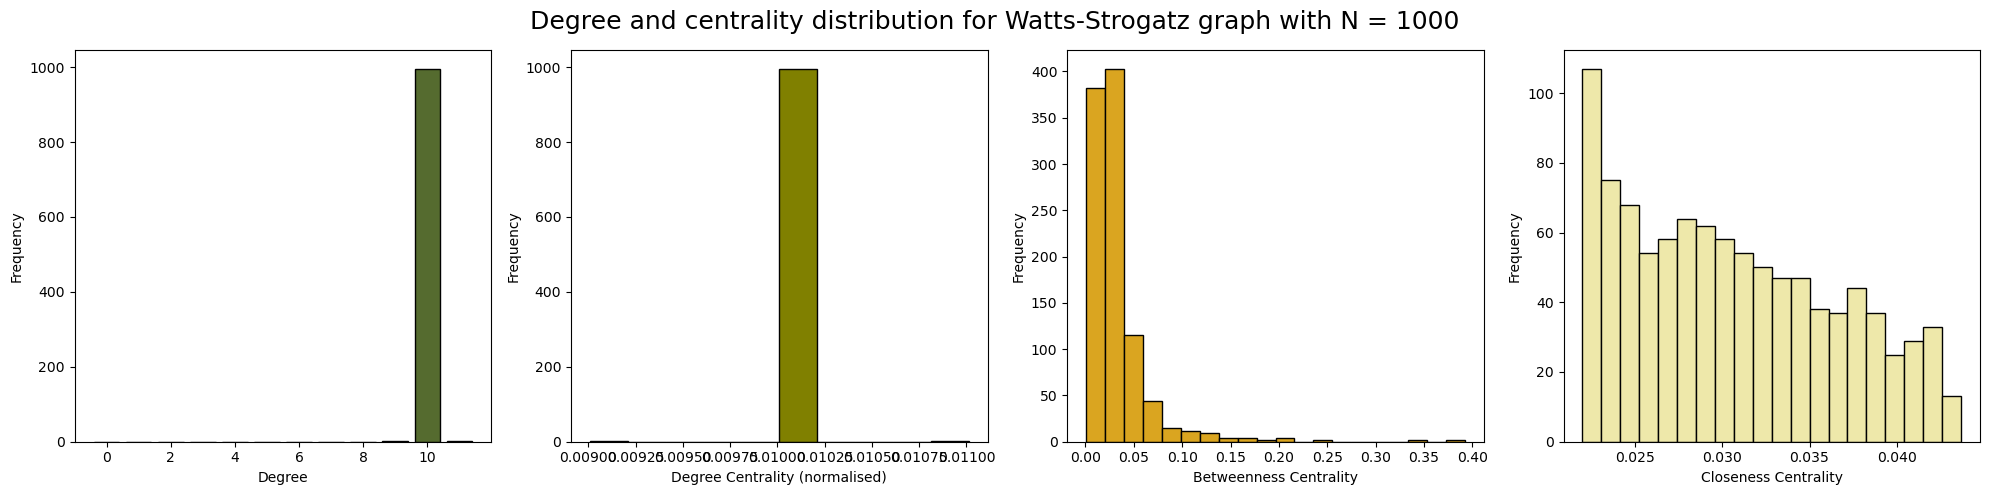

In [604]:
# Generate networks
seed = 10
num_nodes = 1000

# Erdos-Renyi
er_network_1 = create_network('Erdos-Renyi', num_nodes, seed = seed, p = 0.01)

# Barabasi-Albert
ba_network_1 = create_network('Barabasi-Albert', num_nodes, seed = seed, m = 5)

# Watts-Strogatz
ws_network_1 = create_network('Watts-Strogatz', num_nodes, seed = seed, k = 10, p = 0.001)

# Print basic statistics
print('Erdos-Renyi')
print_basic_network_statistics(er_network_1)
print('Barabasi-Albert')
print_basic_network_statistics(ba_network_1)
print('Watts-Strogatz')
print_basic_network_statistics(ws_network_1)

# Plot histograms
plot_network_histograms(er_network_1, 'Degree and centrality distribution for Erdos-Renyi graph with N = 1000')
plot_network_histograms(ba_network_1, 'Degree and centrality distribution for Barabasi-Albert graph with N = 1000')
plot_network_histograms(ws_network_1, 'Degree and centrality distribution for Watts-Strogatz graph with N = 1000')

#### Heavily connected networks

Erdos-Renyi
Diameter = 3
Average path length = 1.9001561561561562
Average degree = 99.79
Clustering coefficient = 0.09973648605439032
Number of edges = 49895
------------------------------------
Barabasi-Albert
Diameter = 3
Average path length = 1.9070850850850851
Average degree = 95.0
Clustering coefficient = 0.17337389443014586
Number of edges = 47500
------------------------------------
Watts-Strogatz
Diameter = 5
Average path length = 3.0224844844844845
Average degree = 100.0
Clustering coefficient = 0.7408039053701289
Number of edges = 50000
------------------------------------


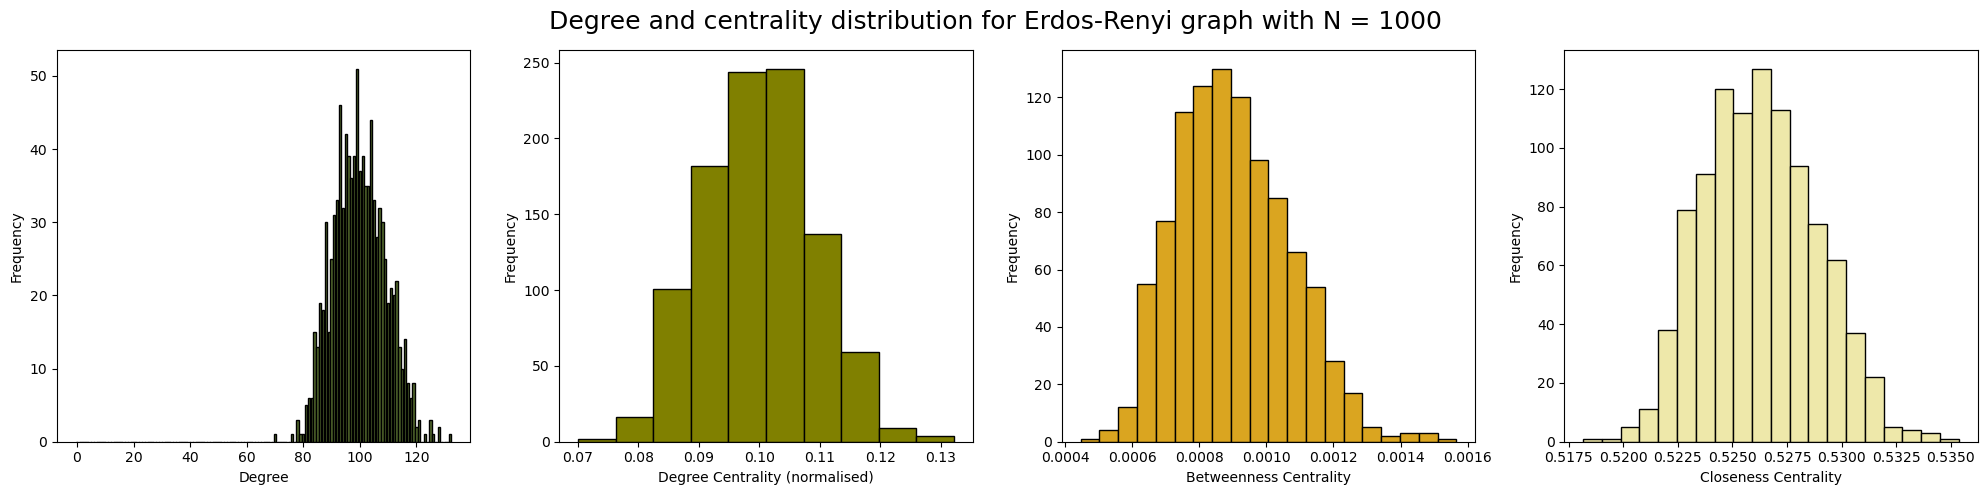

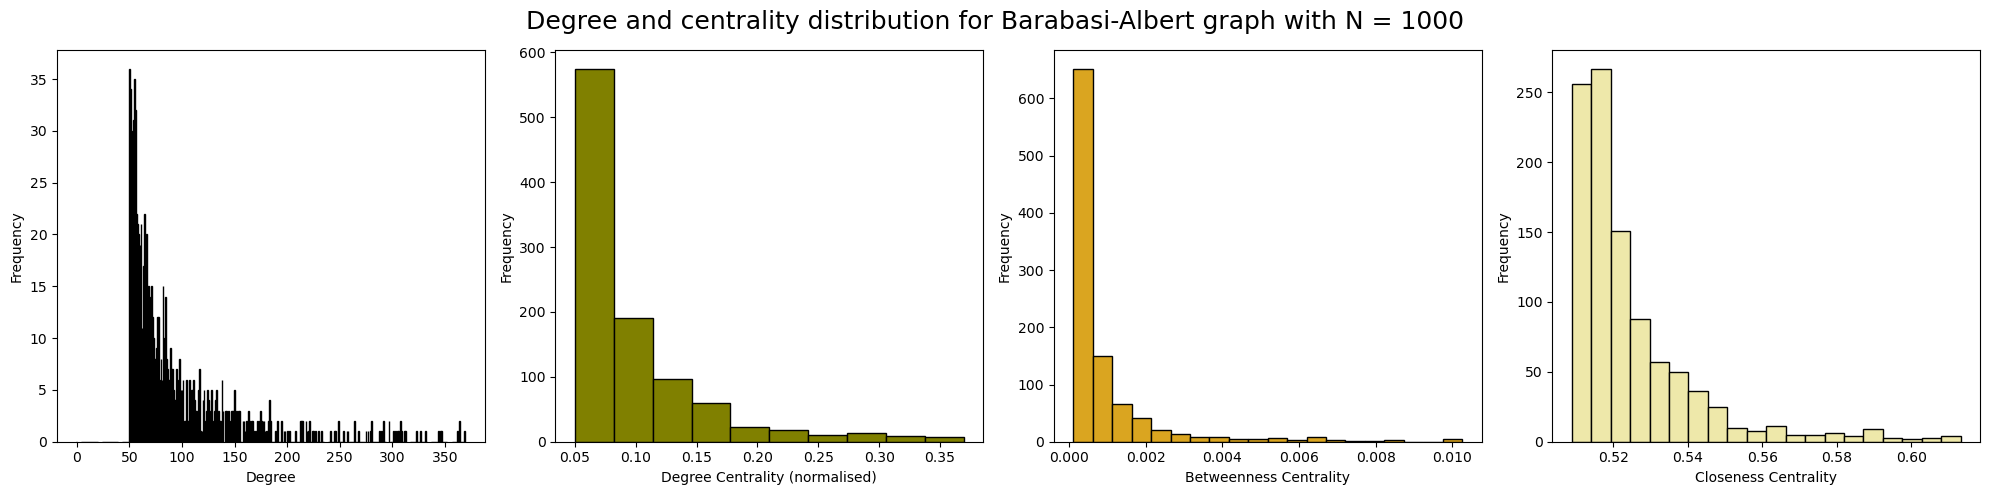

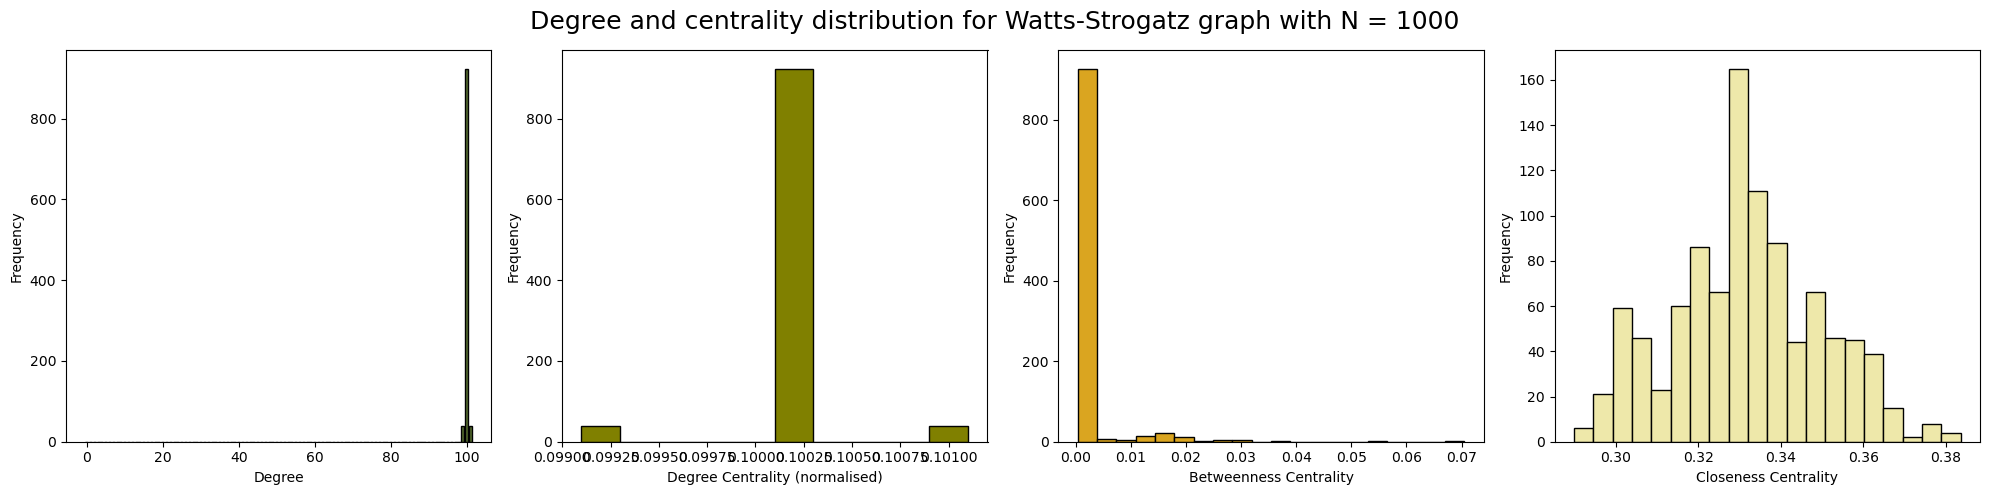

In [448]:
# Generate networks
seed = 10
num_nodes = 1000

# Erdos-Renyi
er_network_2 = create_network('Erdos-Renyi', num_nodes, seed = seed, p = 0.1)

# Barabasi-Albert
ba_network_2 = create_network('Barabasi-Albert', num_nodes, seed = seed, m = 50)

# Watts-Strogatz
ws_network_2 = create_network('Watts-Strogatz', num_nodes, seed = seed, k = 100, p = 0.001)

# Show statistics
print('Erdos-Renyi')
print_basic_network_statistics(er_network_2)
print('Barabasi-Albert')
print_basic_network_statistics(ba_network_2)
print('Watts-Strogatz')
print_basic_network_statistics(ws_network_2)

# Plot histograms
plot_network_histograms(er_network_2, 'Degree and centrality distribution for Erdos-Renyi graph with N = 1000')
plot_network_histograms(ba_network_2, 'Degree and centrality distribution for Barabasi-Albert graph with N = 1000')
plot_network_histograms(ws_network_2, 'Degree and centrality distribution for Watts-Strogatz graph with N = 1000')

#### Small networks

Erdos-Renyi
Diameter = 5
Average path length = 2.6284848484848484
Average degree = 6.62
Clustering coefficient = 0.07197163947163947
Number of edges = 331
------------------------------------
Barabasi-Albert
Diameter = 4
Average path length = 2.5802020202020204
Average degree = 5.82
Clustering coefficient = 0.158658436391195
Number of edges = 291
------------------------------------
Watts-Strogatz
Diameter = 17
Average path length = 8.757575757575758
Average degree = 6.0
Clustering coefficient = 0.6
Number of edges = 300
------------------------------------


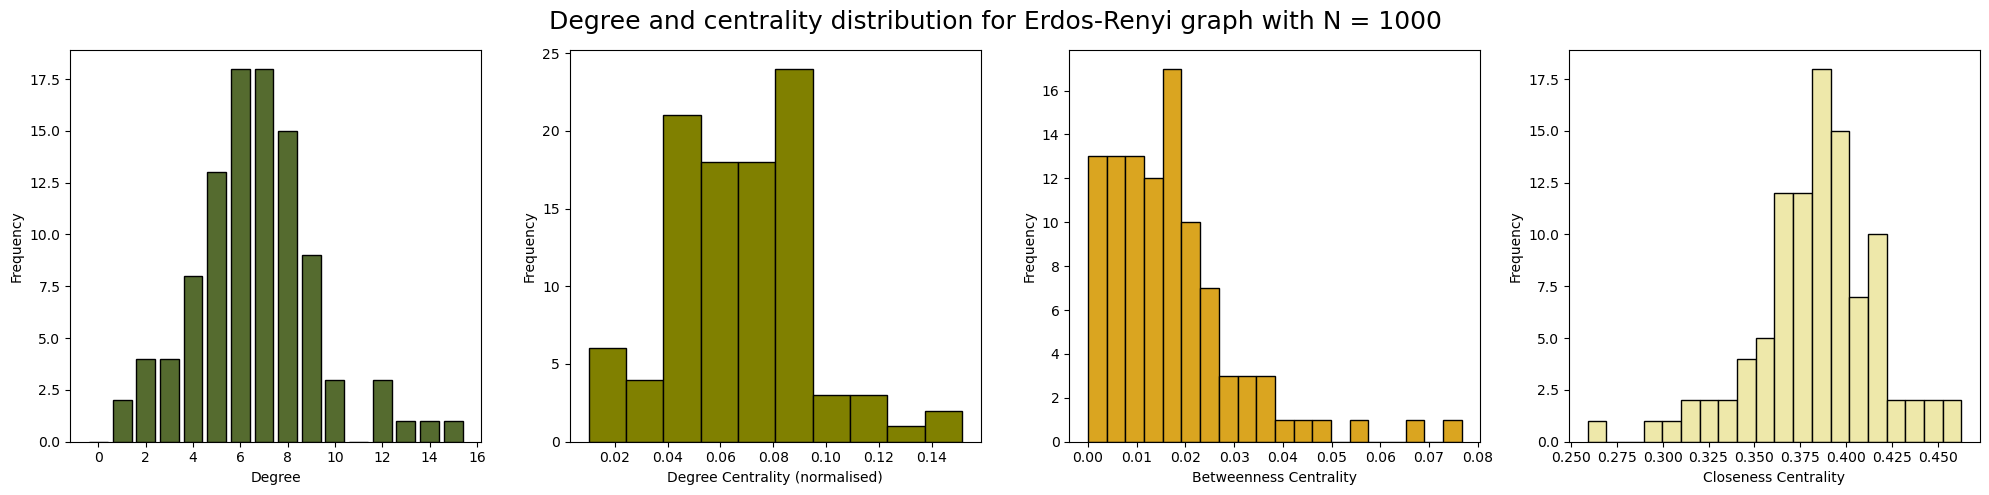

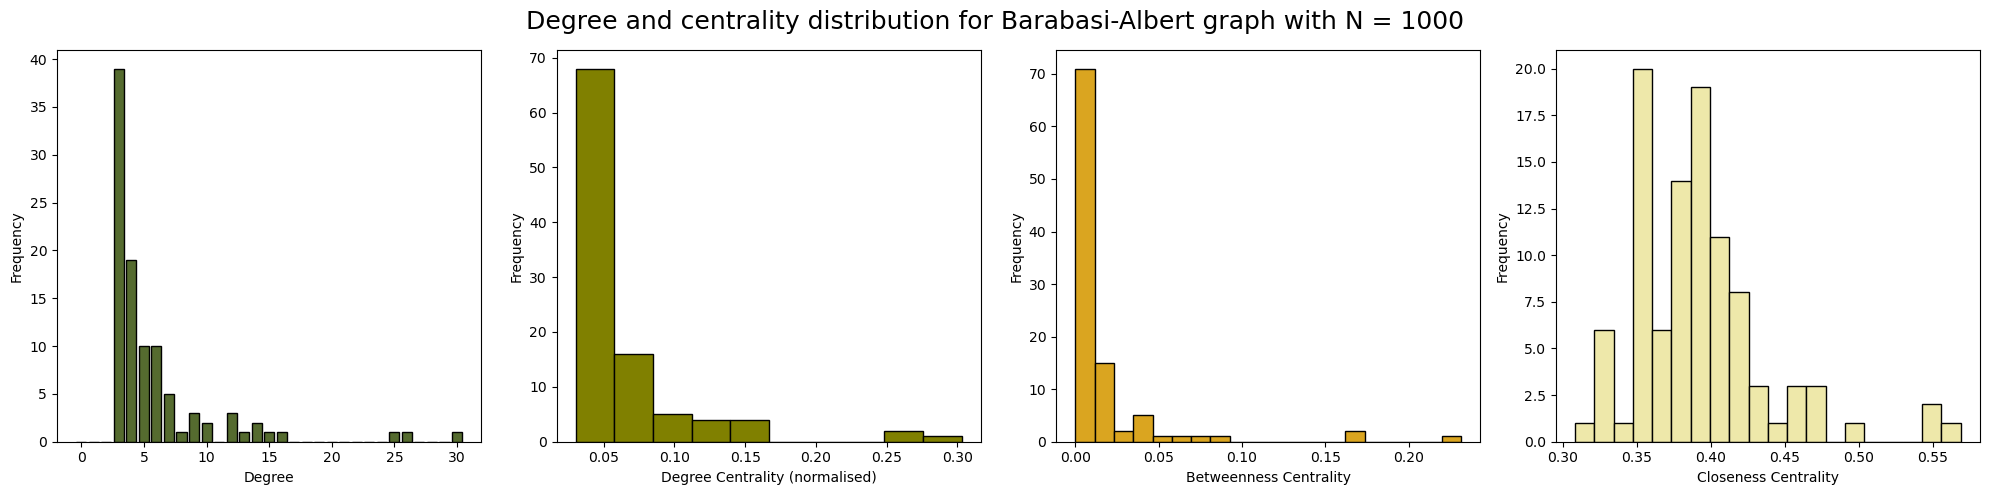

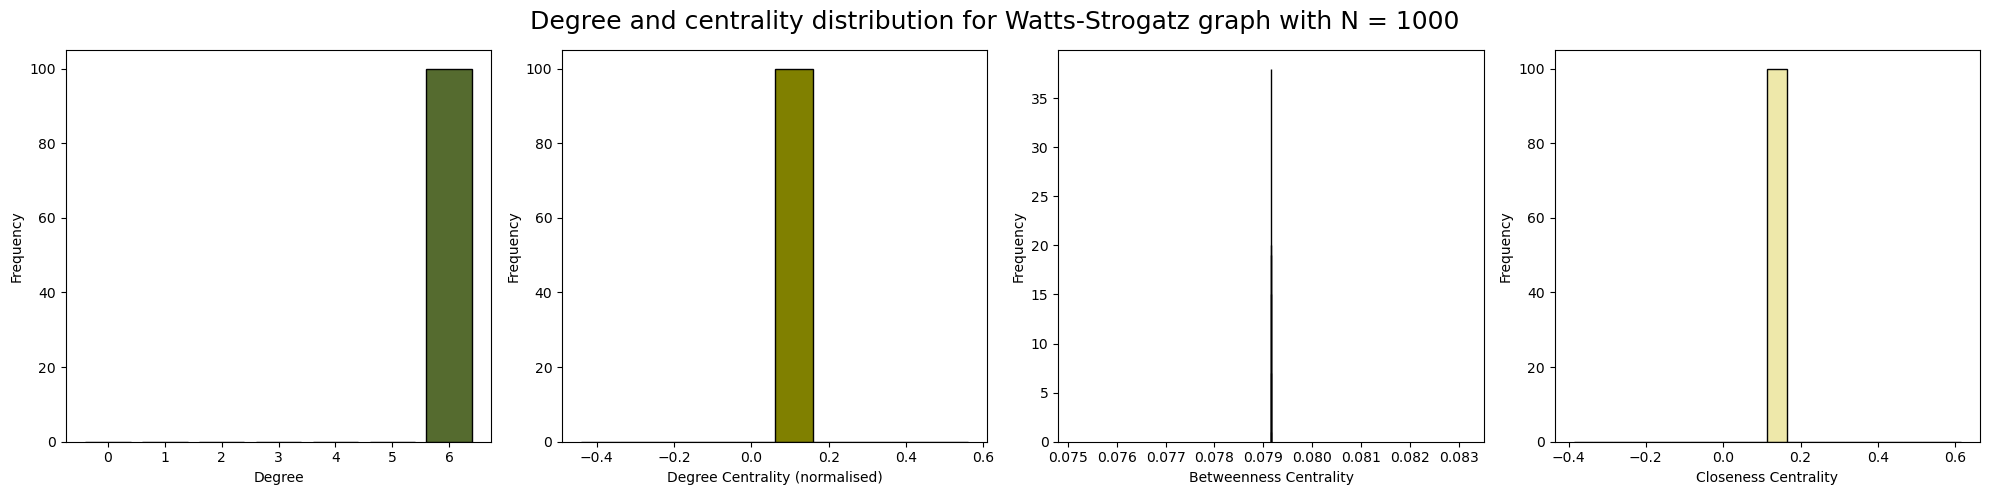

In [452]:
# Generate networks
seed = 10
num_nodes = 100

# Erdos-Renyi
er_network_3 = create_network('Erdos-Renyi', num_nodes, seed = seed, p = 0.07)

# Barabasi-Albert
ba_network_3 = create_network('Barabasi-Albert', num_nodes, seed = seed, m = 3)

# Watts-Strogatz
ws_network_3 = create_network('Watts-Strogatz', num_nodes, seed = seed, k = 6, p = 0.001)

# Show statistics
print('Erdos-Renyi')
print_basic_network_statistics(er_network_3)
print('Barabasi-Albert')
print_basic_network_statistics(ba_network_3)
print('Watts-Strogatz')
print_basic_network_statistics(ws_network_3)

# Plot histograms
plot_network_histograms(er_network_3, 'Degree and centrality distribution for Erdos-Renyi graph with N = 1000')
plot_network_histograms(ba_network_3, 'Degree and centrality distribution for Barabasi-Albert graph with N = 1000')
plot_network_histograms(ws_network_3, 'Degree and centrality distribution for Watts-Strogatz graph with N = 1000')

## 2.3 Simulate SIR spread on the network

Simulate epidemic spreading on the networks you generated in the previous section
(NOTE: the simulations will be stochastic so think about random seeds and repitions).
You can vary the fraction of initial infected, which nodes are initially infected and other
disease parameters. Compare and discuss how the disease spreads in the different networks
under different conditions.

In [456]:
def get_centrality_nodes(network, centrality_type, fraction=0.01, top=True):
    centrality = None
    if centrality_type == 'degree':
        centrality = nx.degree_centrality(network)
    elif centrality_type == 'betweenness':
        centrality = nx.betweenness_centrality(network)
    elif centrality_type == 'closeness':
        centrality = nx.closeness_centrality(network)
    else:
        raise ValueError("Invalid centrality type. Choose from 'degree', 'betweenness', or 'closeness'.")

    sorted_nodes = sorted(centrality.items(), key=lambda item: item[1], reverse=top)
    num_infected = int(fraction * len(network.nodes))
    
    return [node for node, _ in sorted_nodes[:num_infected]]

In [526]:
def plot_multiple_trends(trends):
    # Plot the first one and include labels
    first_result = trends[0]['trends']['node_count']
    num_iterations = np.arange(len(first_result[0]))
    
    plt.plot(iterations, first_result[0], color='blue', alpha=0.01, label = 'Susceptible')
    plt.plot(iterations, first_result[1], color='red', alpha=0.01, label = 'Infected')
    plt.plot(iterations, first_result[2], color='green', alpha=0.01, label = 'Recovered')

    # Plot the rest (we assume there is more than 1 result)
    for result in trends[1:]:
        data = result['trends']['node_count']
        
        plt.plot(iterations, data[0], color='blue', alpha=0.01)
        plt.plot(iterations, data[1], color='red', alpha=0.01)
        plt.plot(iterations, data[2], color='green', alpha=0.01)

In [622]:
def plot_mean_trends(trends, linestyle, labels, plot = plt):
    # Get the number of simulations and iterations
    num_simulations = len(trends)
    num_iterations = len(trends[0]['trends']['node_count'][0])

    # Initialize arrays for trends data
    susceptible = np.zeros((num_simulations, num_iterations))
    infected = np.zeros((num_simulations, num_iterations))
    recovered = np.zeros((num_simulations, num_iterations))

    # Add the trends row by row
    for i, result in enumerate(trends):
        data = result['trends']['node_count']
        susceptible[i, :] = data[0]
        infected[i, :] = data[1]
        recovered[i, :] = data[2]

    # Calculate the mean
    mean_susceptible = np.mean(susceptible, axis=0)
    mean_infected = np.mean(infected, axis=0)
    mean_recovered = np.mean(recovered, axis=0)

    # Get the x axis
    iterations = np.arange(num_iterations)

    # Plot the mean trends
    plot.plot(iterations, mean_susceptible, color = 'red', linestyle=linestyle, label = labels[0])
    plot.plot(iterations, mean_infected, color = 'blue', linestyle=linestyle, label = labels[1])
    plot.plot(iterations, mean_recovered, color = 'green', linestyle=linestyle, label = labels[2])

    plot.legend()

#### Compare different number of initially infected nodes

In [652]:
def plot_sir_different_init_infected_number(er_network, ba_network, ws_network, beta, gamma, iterations, num_simulations, N, k, save = False):
    # Initialize a 1x3 grid of plots
    fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    initially_infected_numbers = [1, 5, 10]
    
    # Loop through each option for initially infected nodes
    for idx, initially_infected in enumerate(initially_infected_numbers):
        # Generate initial infected nodes for this configuration
        initial_infected_nodes = np.random.choice(list(er_network.nodes()), initially_infected, replace=False)
    
        # Run simulations for each network type with current initial infected nodes
        er_trends = run_sir_simulations(er_network, beta, gamma, initial_infected_nodes=initial_infected_nodes, iterations=iterations, num_simulations=num_simulations)
        ba_trends = run_sir_simulations(ba_network, beta, gamma, initial_infected_nodes=initial_infected_nodes, iterations=iterations, num_simulations=num_simulations)
        ws_trends = run_sir_simulations(ws_network, beta, gamma, initial_infected_nodes=initial_infected_nodes, iterations=iterations, num_simulations=num_simulations)
    
        # Plot each trend on the corresponding subplot
        plot_mean_trends(er_trends, '-', ['Susceptible (ER)', 'Infected (ER)', 'Recovered (ER)'], axs[idx])
        plot_mean_trends(ba_trends, '--', ['Susceptible (BA)', 'Infected (BA)', 'Recovered (BA)'], axs[idx])
        plot_mean_trends(ws_trends, ':', ['Susceptible (WS)', 'Infected (WS)', 'Recovered (WS)'], axs[idx])
    
        # Set titles and labels for the subplot
        axs[idx].set_title(f'# of initially infected nodes = {initially_infected}')
        axs[idx].set_xlabel('Iterations')
        axs[idx].grid(True)
        if idx == 0:
            axs[idx].set_ylabel('# Individuals in Each Compartment')
    
    # Overall title
    plt.suptitle(f'Mean of SIR simulations for different network types with N = {N} and <k> = {k} and various numbers of initially infected nodess', fontsize=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit titles
    if save:
        plt.savefig(f'various_init_nodes_{N}_{k}.pdf', dpi = 150)
    plt.show()

In [ ]:
# Plot for all variants of the networks
betas = [1/10, 1/100, 1/6]
gamma = 1/10
iterations = 100
num_simulations = 30

plot_sir_different_init_infected_number(er_network_1, ba_network_1, ws_network_1, betas[0], gamma, iterations, num_simulations, N = 1000, k = 10, save = True)
plot_sir_different_init_infected_number(er_network_2, ba_network_2, ws_network_2, betas[1], gamma, iterations, num_simulations, N = 1000, k = 100, save = True)
plot_sir_different_init_infected_number(er_network_3, ba_network_3, ws_network_3, betas[2], gamma, iterations, num_simulations, N = 100, k = 6, save = True)

#### Compare different value of spreading rate lambda

In [694]:
def plot_sir_different_lambda(er_network, ba_network, ws_network, betas, iterations, num_simulations, N, k, save = False):
    # Initialize a 1x3 grid of plots
    fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    # Generate 5 initial infected nodes
    initial_infected_nodes = np.random.choice(list(er_network.nodes()), 5, replace=False)

    gamma = 1/10
    
    # Loop through each option for initially infected nodes
    for idx, beta in enumerate(betas):
        # Run simulations for each network type with current value of beta
        er_trends = run_sir_simulations(er_network, beta, gamma, initial_infected_nodes=initial_infected_nodes, iterations=iterations, num_simulations=num_simulations)
        ba_trends = run_sir_simulations(ba_network, beta, gamma, initial_infected_nodes=initial_infected_nodes, iterations=iterations, num_simulations=num_simulations)
        ws_trends = run_sir_simulations(ws_network, beta, gamma, initial_infected_nodes=initial_infected_nodes, iterations=iterations, num_simulations=num_simulations)
    
        # Plot each trend on the corresponding subplot
        plot_mean_trends(er_trends, '-', ['Susceptible (ER)', 'Infected (ER)', 'Recovered (ER)'], axs[idx])
        plot_mean_trends(ba_trends, '--', ['Susceptible (BA)', 'Infected (BA)', 'Recovered (BA)'], axs[idx])
        plot_mean_trends(ws_trends, ':', ['Susceptible (WS)', 'Infected (WS)', 'Recovered (WS)'], axs[idx])
    
        # Set titles and labels for the subplot
        axs[idx].set_title(rf'$\beta$ = {beta:.3f}, $\gamma$ = {gamma}, $\lambda$ = {beta/gamma:.3f}')
        axs[idx].set_xlabel('Iterations')
        axs[idx].grid(True)
        if idx == 0:
            axs[idx].set_ylabel('# Individuals in Each Compartment')
    
    # Overall title
    plt.suptitle(rf'Mean of SIR simulations for different network types with N = {N} and <k> = {k} and various $\lambda$', fontsize=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit titles
    if save:
        plt.savefig(f'various_lambda_{N}_{k}_v2.pdf', dpi = 150)
    plt.show()

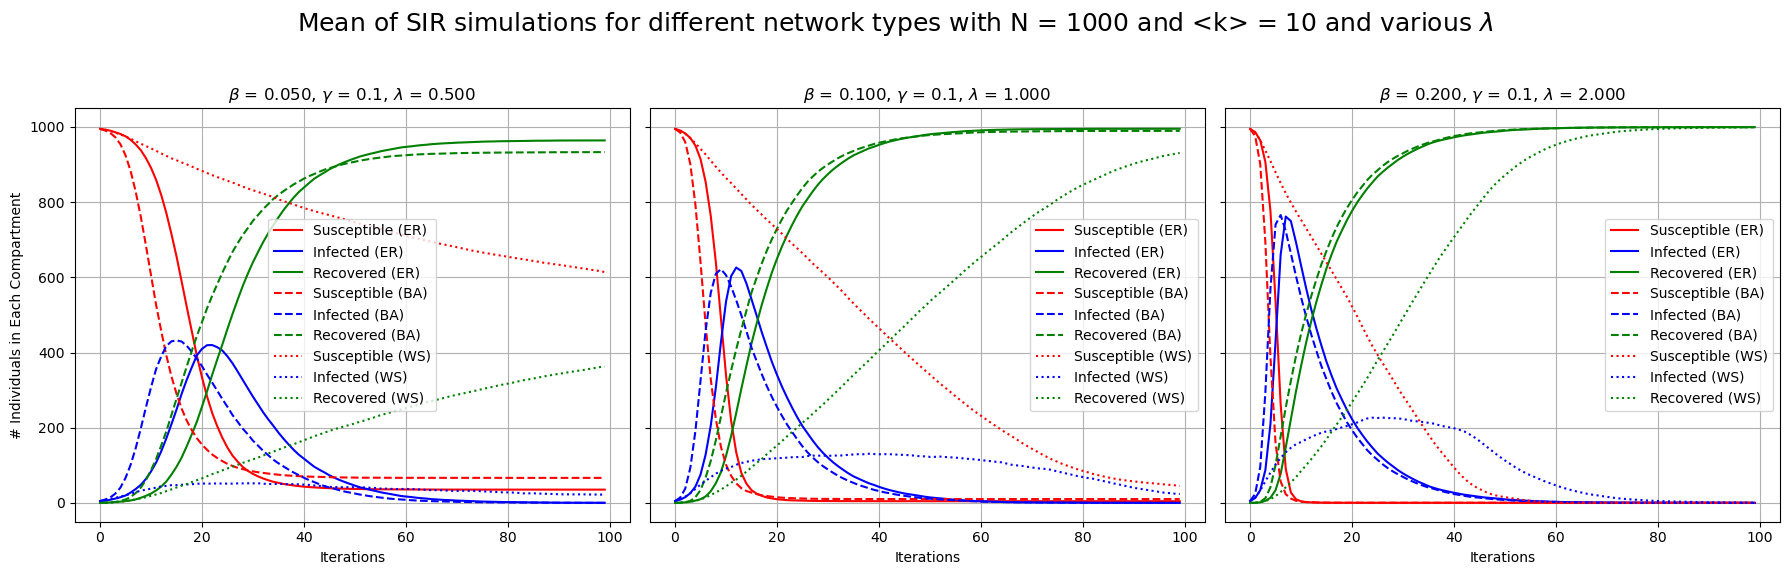

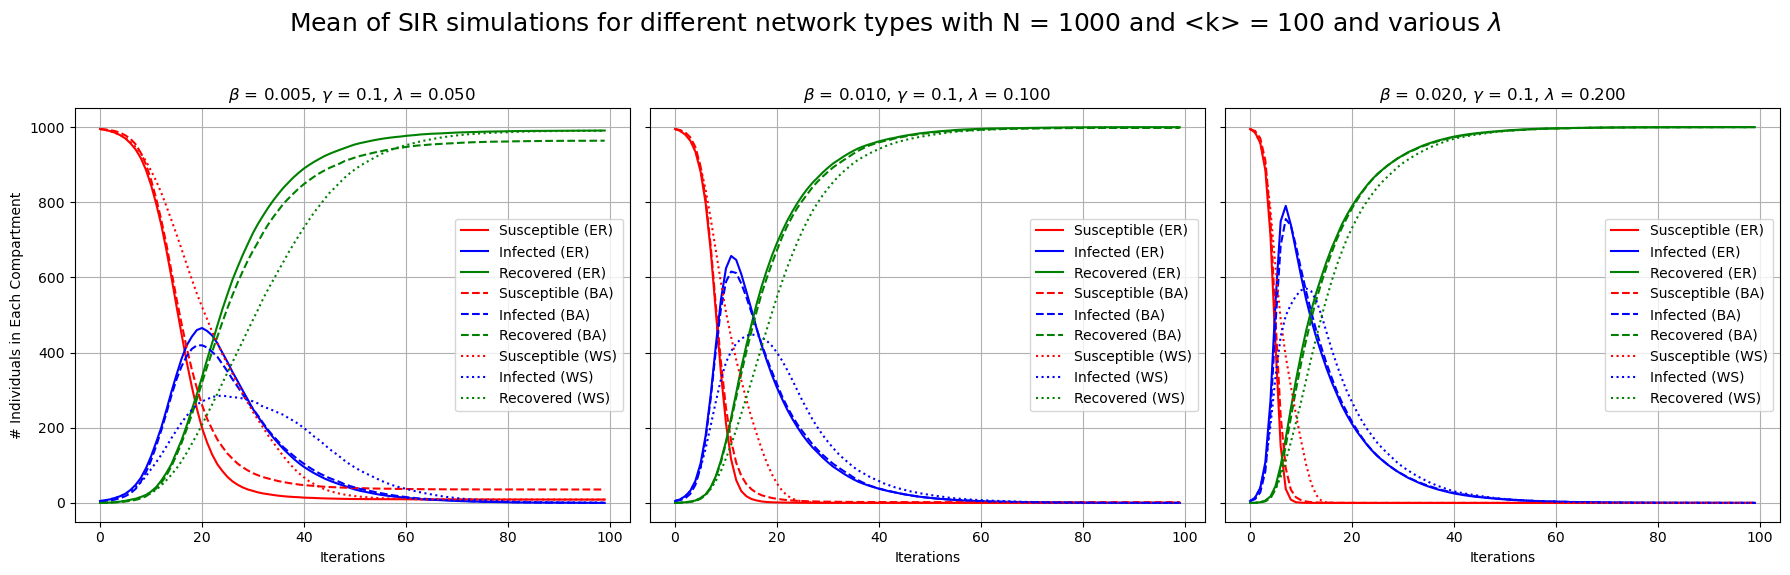

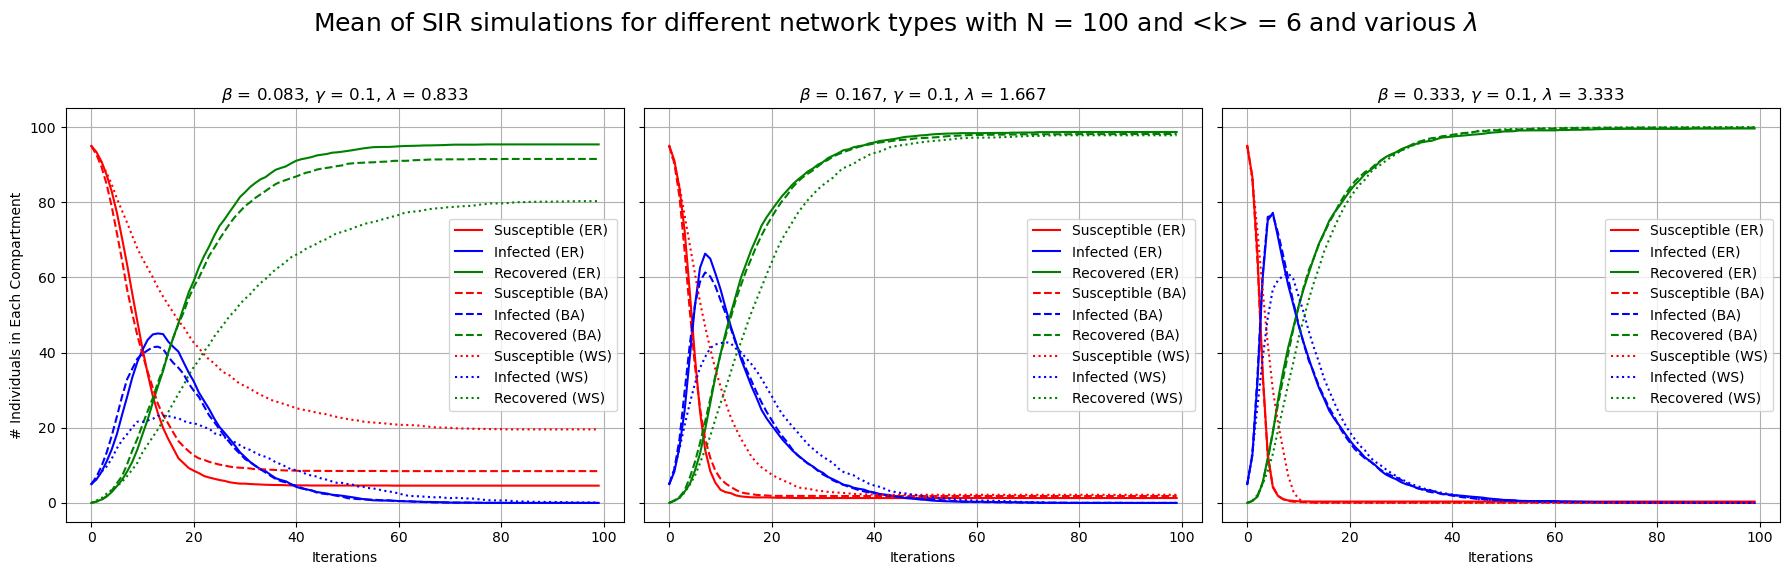

In [696]:
# Plot for all variants of the networks
iterations = 100
num_simulations = 30
betas_1 = [1/20, 1/10, 1/5]
betas_2 = [1/200, 1/100, 1/50]
betas_3 = [1/12, 1/6, 1/3]

plot_sir_different_lambda(er_network_1, ba_network_1, ws_network_1, betas_1, iterations, num_simulations, N = 1000, k = 10, save = True)
plot_sir_different_lambda(er_network_2, ba_network_2, ws_network_2, betas_2, iterations, num_simulations, N = 1000, k = 100, save = True)
plot_sir_different_lambda(er_network_3, ba_network_3, ws_network_3, betas_3, iterations, num_simulations, N = 100, k = 6, save = True)

#### Compare different choice of initially infected nodes

In [681]:
def plot_sir_different_init_centrality(er_network, ba_network, ws_network, beta, gamma, iterations, num_simulations, N, k, save = False):
    # Initialize a 1x3 grid of plots
    fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    get_centrality_nodes(network, centrality_type, fraction=0.01, top=True)
    centrality_types = ['degree', 'betweenness', 'closeness']
    
    # Loop through each option for initially infected nodes
    for idx, centrality_type in enumerate(centrality_types):
        # Generate initial infected nodes for this configuration
        initial_infected_nodes_er = get_centrality_nodes(er_network, centrality_type, fraction=5/N, top=True)
        initial_infected_nodes_ba = get_centrality_nodes(er_network, centrality_type, fraction=5/N, top=True)
        initial_infected_nodes_ws = get_centrality_nodes(er_network, centrality_type, fraction=5/N, top=True)
    
        # Run simulations for each network type with current initial infected nodes
        er_trends = run_sir_simulations(er_network, beta, gamma, initial_infected_nodes=initial_infected_nodes_er, iterations=iterations, num_simulations=num_simulations)
        ba_trends = run_sir_simulations(ba_network, beta, gamma, initial_infected_nodes=initial_infected_nodes_ba, iterations=iterations, num_simulations=num_simulations)
        ws_trends = run_sir_simulations(ws_network, beta, gamma, initial_infected_nodes=initial_infected_nodes_ws, iterations=iterations, num_simulations=num_simulations)
    
        # Plot each trend on the corresponding subplot
        plot_mean_trends(er_trends, '-', ['Susceptible (ER)', 'Infected (ER)', 'Recovered (ER)'], axs[idx])
        plot_mean_trends(ba_trends, '--', ['Susceptible (BA)', 'Infected (BA)', 'Recovered (BA)'], axs[idx])
        plot_mean_trends(ws_trends, ':', ['Susceptible (WS)', 'Infected (WS)', 'Recovered (WS)'], axs[idx])
    
        # Set titles and labels for the subplot
        axs[idx].set_title(f'Centrality type of infected nodes = {centrality_type}')
        axs[idx].set_xlabel('Iterations')
        axs[idx].grid(True)
        if idx == 0:
            axs[idx].set_ylabel('# Individuals in Each Compartment')
    
    # Overall title
    plt.suptitle(f'Mean of SIR simulations for different network types with N = {N} and <k> = {k} and different infected nodes by centrality', fontsize=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit titles
    if save:
        plt.savefig(f'various_init_nodes_centrality_{N}_{k}.pdf', dpi = 150)
    plt.show()

In [ ]:
# Plot for all variants of the networks
betas = [1/10, 1/100, 1/6]
gamma = 1/10
iterations = 100
num_simulations = 30

plot_sir_different_init_centrality(er_network_1, ba_network_1, ws_network_1, betas[0], gamma, iterations, num_simulations, N = 1000, k = 10, save = True)
plot_sir_different_init_centrality(er_network_2, ba_network_2, ws_network_2, betas[1], gamma, iterations, num_simulations, N = 1000, k = 100, save = True)
plot_sir_different_init_centrality(er_network_3, ba_network_3, ws_network_3, betas[2], gamma, iterations, num_simulations, N = 100, k = 6, save = True)

## 2.4 Dynamic Vaccination Campaign

Finally, we will conduct vaccination experiments using the sociopatterns dataset, see
Figure 1. You should design some code to load in the sociopatterns dataset (this file on
canvas includes a simple edgelist and NDLib and NetworkX provide ways to import this).

Now consider a scenario in which a disease is spreading on this network. You should run
multiple experiments, but assume that the disease always starts with a random selection
of 5 nodes infected.

You are to design a dynamic vaccination strategy in which you have a testing budget and
a limited number of vaccinations available per iteration of the model. Assume that you
have 200 tests in total, you can use a maximum number of tests per iteration (this will
vary per experiment see below), you can of course use less. You can use the tests at any
point during the spread and you may repeat tests on a node as often as you like. You
can assume that you know the network structure, but you can only discover the disease
status of a node after a test. Vaccinations can only be applied to susceptible people and
that they immediately move people to the removed state. Finally, you might consider
situations where the tests are not always accurate, but instead have some probability
(which you can vary) of being accurate. You can also assume that people remain removed
until the end of the simulation (no waning immunity).
You should compare your strategy against a simple null strategy which randomly assigns
vaccinations, you should design a strategy that at least out performs the null strategy.
Compare the strategies with different vaccination budgets of [1, 3, 5 and 10] per timestep
and compare with different testing accuracy [0.5, 0.75, 1.0] . Finally, keep in mind that
the purpose of the assignment is not to design the best strategy, but to evaluate you
strategy in a systematic and scientific manner.

### Load edgelist and generate a network from it

In [687]:
def generate_conference_network():
    # Load the CSV data into a matrix
    nodes_and_edges_matrix = np.genfromtxt('transmission_network.csv', delimiter = ';')
    
    # Get the nodes and edges
    nodes = nodes_and_edges_matrix[1:,0]
    edges_matrix = nodes_and_edges_matrix[1:,1:]
    
    num_nodes = len(nodes)
    nodes = [str(node) for node in nodes]
    
    # Initialize the network with all the nodes
    network = nx.Graph()
    network.add_nodes_from(nodes)
    
    # Add the edges to the network
    for row in range(num_nodes):
        for col in range(row + 1, num_nodes):
            if edges_matrix[row, col] != 0:
                network.add_edge(nodes[row], nodes[col])
                
    return network

### Run SIR simulation without vaccination

In [689]:
# Set parameters
network = generate_conference_network()
beta = 1/15
gamma = 1/10
initial_infected_fraction = 5/num_nodes # we have 5 random infected nodes at the beginning

trends = run_sir_simulations(network, beta, gamma, initial_infected_fraction = initial_infected_fraction, iterations = 100, num_simulations = 30)

# Plot
plot_mean_trends(trends, linestyle = '-', labels = ['Susceptible', 'Infected', 'Recovered'], plot = plt)

plt.title('SIR simulation on network') # TODO: improve
plt.xlabel('Iterations') # TODO: improve
plt.ylabel('Population') # TODO: improve
plt.tight_layout()
plt.show()

NameError: name 'run_sir_simulation' is not defined

### Null strategy

In [ ]:
def simulate_null_vaccination_strategy(network, beta, gamma, initial_infected_nodes, vaccination_budget, max_iterations = 100):
    model = generate_model(network, beta, gamma, initial_infected_nodes)

    # Initially, no node was vaccinated yet
    not_vaccinated_nodes = list(network.nodes())

    # Initialize variables
    susceptibles = [369] # 374 - 5 who were initially infected
    infecteds = [5]
    recovered = [0]
    extinction = False
    vaccinations_used = 0

    for iteration in range(max_iterations):
        # Run an iteration
        result = model.iteration()
    
        # Check that there are still some infecteds left
        if result['node_count'][1] < 1:
            extinction = True
            break

        # Add the result to the respective lists
        susceptibles.append(result['node_count'][0])
        infecteds.append(result['node_count'][1])
        recovered.append(result['node_count'][2])
    
        # Get the current status of the nodes
        status = model.status
    
        # Pick nodes that are supposed to be vaccinated randomly
        if len(not_vaccinated_nodes) < vaccination_budget:
            nodes_to_vaccinate = not_vaccinated_nodes
        else:
            nodes_to_vaccinate = np.random.choice(not_vaccinated_nodes, vaccination_budget, replace = False)
        
        # Vaccinate by changing the status (vaccination only works when not infected, so the only chage is from S -> R)
        for node in nodes_to_vaccinate:
            # Remove node from the list of not vaccinated nodes
            not_vaccinated_nodes.remove(node)
            # We vaccinate every node maximum once. Even if we do not test, either the node was sucsceptible and it goes to R, or it was alredy in R or in I and once it recovers it will go to R.
            if status[node] == 0:
                model.status[node] = 2

        vaccinations_used += len(nodes_to_vaccinate)
    
    return {'susceptibles': susceptibles, 'infecteds': infecteds, 'recovered': recovered, 'extinction': extinction, 'vaccinations_used': vaccinations_used, 'number_of_iterations': iteration + 1}

In [ ]:
# Test one run of the null strategy
network = generate_conference_network()
beta = 1/15
gamma = 1/10
vaccination_budget = 5
initial_infected_nodes = np.random.choice(list(network.nodes()), vaccination_budget, replace=False)
max_iterations = 100

simulation_result = simulate_null_vaccination_strategy(network, beta, gamma, initial_infected_nodes, vaccination_budget, max_iterations)